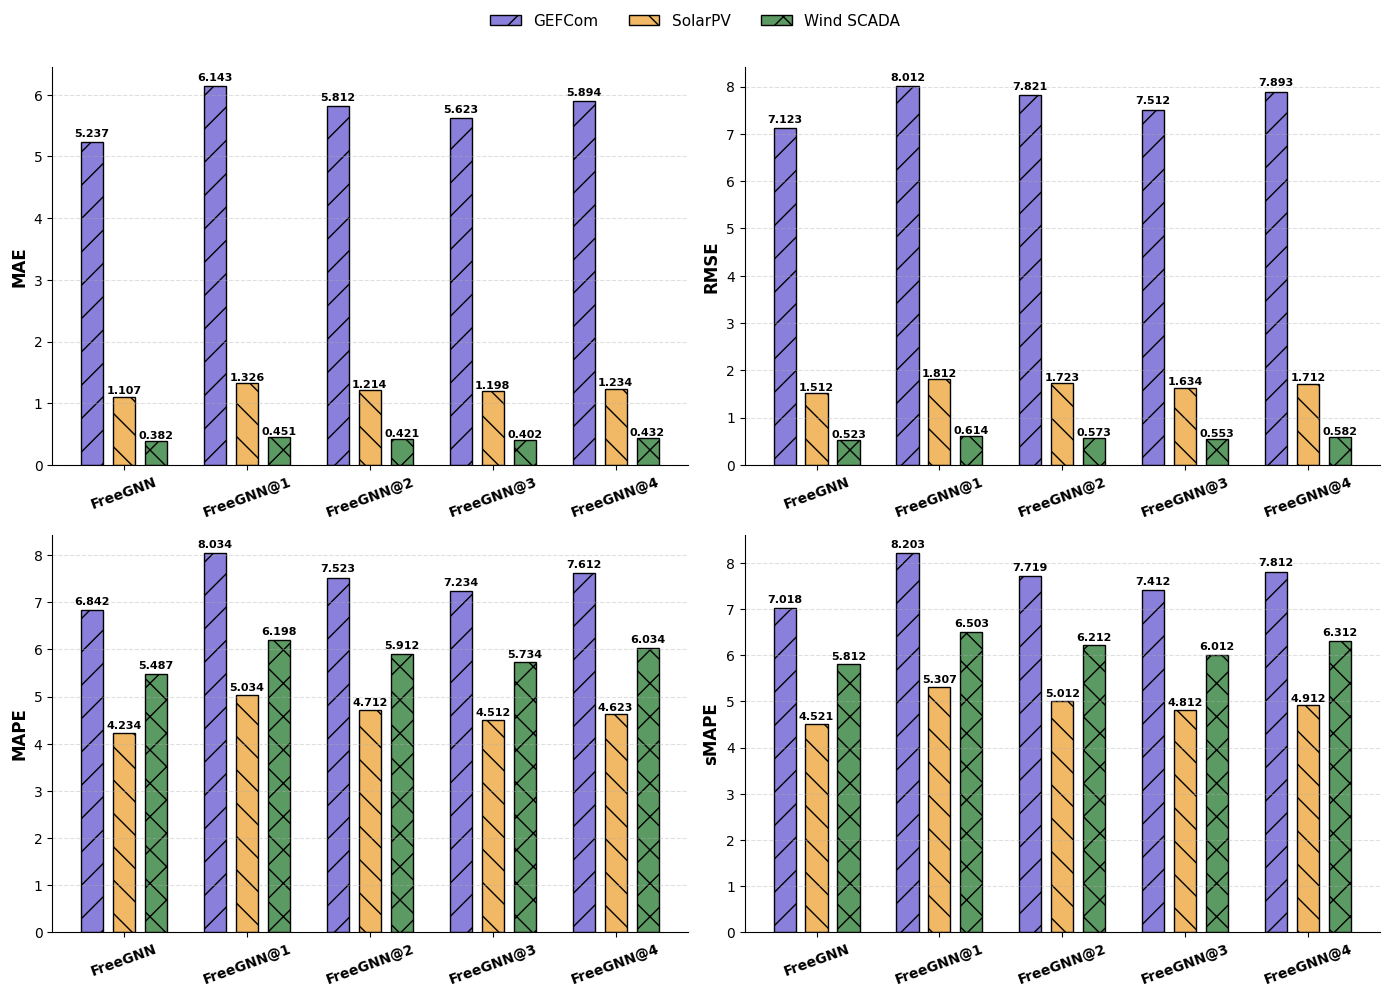

In [1]:
import numpy as np
import matplotlib.pyplot as plt

models = ['FreeGNN','FreeGNN@1','FreeGNN@2','FreeGNN@3','FreeGNN@4']
datasets = ['GEFCom','SolarPV','Wind SCADA']

MAE = np.array([
    [5.237, 1.107, 0.382],
    [6.143, 1.326, 0.451],
    [5.812, 1.214, 0.421],
    [5.623, 1.198, 0.402],
    [5.894, 1.234, 0.432]
])

RMSE = np.array([
    [7.123, 1.512, 0.523],
    [8.012, 1.812, 0.614],
    [7.821, 1.723, 0.573],
    [7.512, 1.634, 0.553],
    [7.893, 1.712, 0.582]
])

MAPE = np.array([
    [6.842, 4.234, 5.487],
    [8.034, 5.034, 6.198],
    [7.523, 4.712, 5.912],
    [7.234, 4.512, 5.734],
    [7.612, 4.623, 6.034]
])

sMAPE = np.array([
    [7.018, 4.521, 5.812],
    [8.203, 5.307, 6.503],
    [7.719, 5.012, 6.212],
    [7.412, 4.812, 6.012],
    [7.812, 4.912, 6.312]
])

metrics = [MAE, RMSE, MAPE, sMAPE]
metric_names = ['MAE','RMSE','MAPE','sMAPE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(len(models))

width = 0.18
spacing = 0.08

hatches = ['/', '\\', 'x']
colors = ['#8A7FDB', '#F1B865', '#5C9A63']

for ax, metric, name in zip(axes, metrics, metric_names):

    for i in range(3):
        bars = ax.bar(
            x + (i-1)*(width + spacing),
            metric[:, i],
            width,
            label=datasets[i],
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            hatch=hatches[i]
        )

        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height * 1.01,
                f'{height:.3f}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold'
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, fontweight='bold')
    ax.set_ylabel(name, fontsize=12, fontweight='bold')

    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, fontsize=11)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("/kaggle/working/Ablation_Clean.pdf",
            format="pdf",
            bbox_inches="tight",
            dpi=600)
plt.show()